In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from scipy.interpolate import interp1d
from scipy.optimize import root_scalar
import gurobipy as gp
from gurobipy import GRB

from sklearn.decomposition import PCA
from sklearn.cluster import MeanShift, estimate_bandwidth

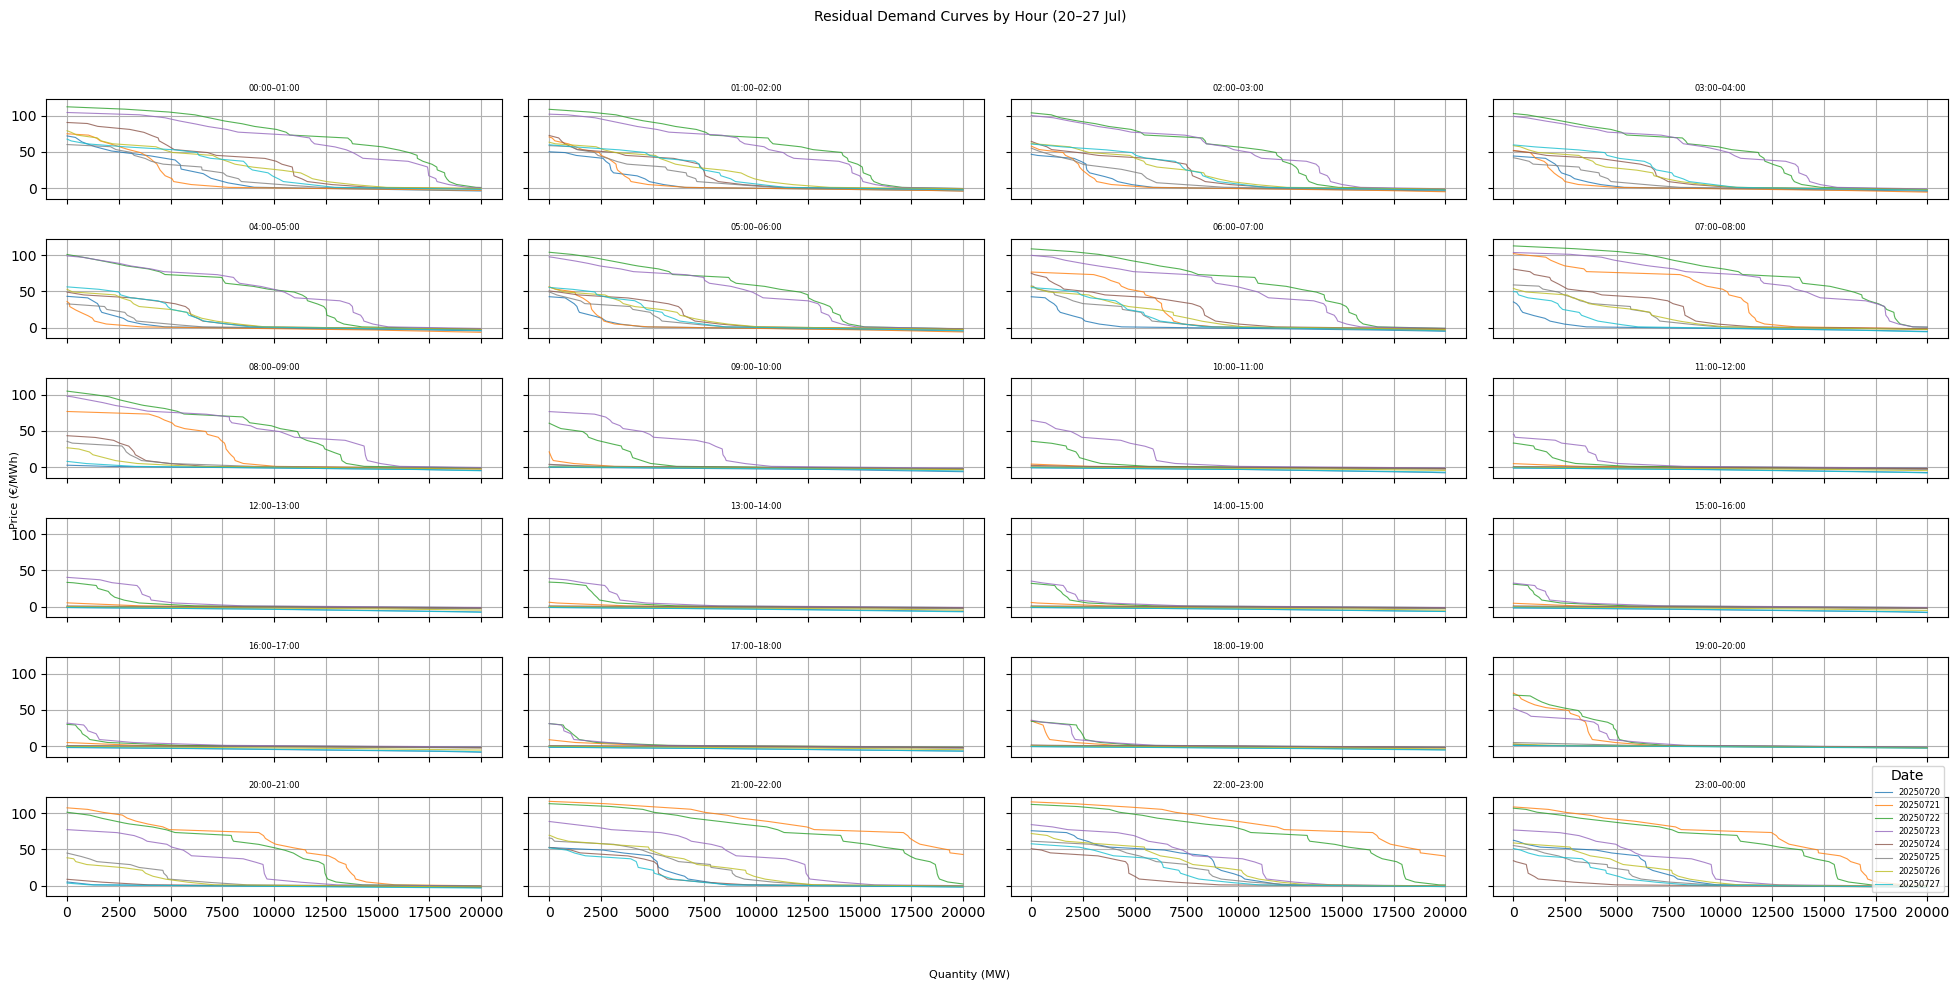

In [ ]:
# --- A) RDC 계산 함수 (생략) ---
def compute_rdc_by_sign_change(price_grid, demand_vals, supply_vals, wf_offers):
    rdc = []
    for q in wf_offers:
        resid = demand_vals - supply_vals - q
        idx   = np.where(np.diff(np.sign(resid)) != 0)[0]
        for i in idx:
            p0,p1 = price_grid[i], price_grid[i+1]
            r0,r1 = resid[i], resid[i+1]
            if r1!=r0:
                p_star = p0 - r0*(p1-p0)/(r1-r0)
                rdc.append((q,p_star))
    return rdc

# --- B) 공통 설정 ---
days          = range(20,30)                 # 7/20~7/27
colors        = plt.cm.tab10(np.linspace(0,1,len(days)))
# wf_offer_grid = np.arange(0,20001,100)       # 0,100,…,20000
# wf_offer_grid = np.arange(0, s_agg['Cumul'].max()*1.2, 100)

B             = 500                   # stepwise 블록 개수

# stepwise 파라미터 저장용
qini            = {}
qmax            = {}
lambda_da_block = {}
orig_cp         = {}

# --- C) 4×6 서브플롯 생성 (figsize 10×5) ---
fig, axes = plt.subplots(nrows=6, ncols=4, figsize=(20,10),
                         sharex=True, sharey=True)
axes = axes.flatten()

# --- D) 각 Period(1~24) 에 대해 ---
for period in range(1,25):
    ax = axes[period-1]
    for day, color in zip(days, colors):
        date_str = f"202507{day:02d}"
        fn       = f"filteredcurve_{date_str}.csv"
        try:
            df = pd.read_csv(fn, encoding='utf-8-sig')
        except FileNotFoundError:
            continue

        # 이미 Price/Amount가 float 라고 가정
        sub    = df[df['Time Period']==period]
        sup    = sub[sub['GC']=='V']
        dem    = sub[sub['GC']=='C']
        if sup.empty or dem.empty:
            continue

        # 집계 & 누적
        # 집계 & 누적
        s_agg = sup.groupby('Price')['Amount'] \
                    .sum().reset_index() \
                    .sort_values('Price')
        s_agg['Cumul'] = s_agg['Amount'].cumsum()

        d_agg = dem.groupby('Price')['Amount'] \
                    .sum().reset_index() \
                    .sort_values('Price')
        # 가격 낮을수록 누적이 커져야 하니 역순 누적
        d_agg['Cumul'] = d_agg['Amount'][::-1].cumsum()[::-1]

        # 계단 보간
        s_f = interp1d(
            s_agg['Price'], s_agg['Cumul'],
            kind='previous', bounds_error=False,
            fill_value=(0, s_agg['Cumul'].iat[-1])
        )
        d_f = interp1d(
            d_agg['Price'], d_agg['Cumul'],
            kind='previous', bounds_error=False,
            fill_value=(d_agg['Cumul'].iat[0], 0)
        )

        pg  = np.linspace(s_agg['Price'].min(), d_agg['Price'].max(), 500)
        sv  = s_f(pg)
        dv  = d_f(pg)
        #Original Clearing Price 계산
        def resid0(p): 
            return d_f(p) - s_f(p)   # q=0
        sol0 = root_scalar(resid0,
                           bracket=[pg[0], pg[-1]],
                           method='bisect')
        orig_cp[(date_str, period)] = sol0.root if sol0.converged else np.nan


        # wf_offer_grid = np.arange(
        #     0,
        #     s_agg['Cumul'].max() * 1.2,
        #     100
        # )

        wf_offer_grid = np.arange(
            0,
            20000,
            10
        )
        
        # Residual Demand
        rdc_pts = compute_rdc_by_sign_change(pg, dv, sv, wf_offer_grid)
        if not rdc_pts:
            continue
        qv, pv = zip(*rdc_pts)
        qv = np.array(qv); pv = np.array(pv)

        # ——— stepwise 근사 파라미터 계산 —————————
        q_breaks = np.linspace(0, qv.max(), B+1)
        delta_qs = q_breaks[1:] - q_breaks[:-1]
        for b in range(B):
            mid = 0.5*(q_breaks[b] + q_breaks[b+1])
            # date_str, period, block b 를 키로 사용
            qini   [(date_str, period, b)] = float(q_breaks[b])
            qmax   [(date_str, period, b)] = float(delta_qs[b])
            lambda_da_block[(date_str, period, b)] = float(np.interp(mid, qv, pv))
        # ————————————————————————————————

        # RDC Curve만 플롯
        # ax.plot(qv, pv, 'o-', color=color, label=date_str)
        ax.plot(
            qv, pv,
            '-',                # 실선만
            color=color,
            label=date_str,
            linewidth=0.8,
            alpha=0.8
        )

    # subplot 제목 (예: “00:00–01:00”)
    hh1 = f"{period-1:02d}:00"; hh2 = f"{period%24:02d}:00"
    ax.set_title(f"{hh1}–{hh2}", fontsize=6)
    ax.grid(True)

# --- E) 공통 레이블 & 레이아웃 ---
fig.supxlabel('Quantity (MW)', fontsize=8)
fig.supylabel('Price (€/MWh)', fontsize=8)
fig.suptitle('Residual Demand Curves by Hour (20–27 Jul)', fontsize=10)

# 범례는 맨 마지막 축에만 표시하도록
axes[-1].legend(title='Date', fontsize=6, loc='lower right')

plt.tight_layout(rect=[0,0.03,1,0.95])
plt.show()


mean shift: medoid

In [104]:
# 메도이드 결과 저장용
rep_curve_by_period = {}      # period -> (q_grid, p_rep)   # 대표곡선(메도이드)
rep_meta_by_period  = {}      # period -> (date_str_of_rep)
raw_curves_by_period = {}  # period -> [원시 시나리오 곡선 리스트]
days          = range(20,30)                 # 7/20~7/27
for period in range(1, 25):
    # 1) 이 period에서의 모든 "시나리오(day)"에 대해 RDC(q,p) 수집
    scenario_curves = []   # 각 원소: dict{'date':..., 'q': qv, 'p': pv}
    for day in days:
        date_str = f"202507{day:02d}"
        fn       = f"filteredcurve_{date_str}.csv"
        try:
            df = pd.read_csv(fn, encoding='utf-8-sig')
        except FileNotFoundError:
            continue

        sub = df[df['Time Period'] == period]
        sup = sub[sub['GC'] == 'V']
        dem = sub[sub['GC'] == 'C']
        if sup.empty or dem.empty:
            continue

        s_agg = sup.groupby('Price')['Amount'].sum().reset_index().sort_values('Price')
        s_agg['Cumul'] = s_agg['Amount'].cumsum()

        d_agg = dem.groupby('Price')['Amount'].sum().reset_index().sort_values('Price')
        d_agg['Cumul'] = d_agg['Amount'][::-1].cumsum()[::-1]

        s_f = interp1d(s_agg['Price'], s_agg['Cumul'], kind='previous',
                       bounds_error=False, fill_value=(0, s_agg['Cumul'].iat[-1]))
        d_f = interp1d(d_agg['Price'], d_agg['Cumul'], kind='previous',
                       bounds_error=False, fill_value=(d_agg['Cumul'].iat[0], 0))

        pg = np.linspace(s_agg['Price'].min(), d_agg['Price'].max(), 500)
        sv = s_f(pg)
        dv = d_f(pg)

        # 이 day의 RDC: (q, p*) 포인트들
        rdc_pts = compute_rdc_by_sign_change(pg, dv, sv, wf_offer_grid)
        if not rdc_pts:
            continue
        qv, pv = map(np.asarray, zip(*rdc_pts))
        # 정렬 보장
        idx_sort = np.argsort(qv)
        qv, pv   = qv[idx_sort], pv[idx_sort]

        scenario_curves.append({'date': date_str, 'q': qv, 'p': pv})
        raw_curves_by_period[period] = scenario_curves


    # 2) 시나리오 수가 적으면 스킵
    # if len(scenario_curves) < 2:
    #     continue

    # 3) 공통 q-격자 정의 (최소~최대 공통구간)
    q_min, q_max = 0, 20000
    # q_max = min(curve['q'].max() for curve in scenario_curves)
    # q_min = max(curve['q'].min() for curve in scenario_curves)
    # q_max = min(curve['q'].max() for curve in scenario_curves)
    # q_min = min(curve['q'].min() for curve in scenario_curves)
    # q_max = max(curve['q'].max() for curve in scenario_curves)
    if not np.isfinite(q_min) or not np.isfinite(q_max) or q_max <= q_min:
        continue

    m = 300  # 격자 해상도 (원하면 200~500 사이 조절)
    q_grid = np.linspace(q_min, q_max, m)

    # 4) 각 시나리오의 p(q)를 공통 q_grid에 보간 → (S, m) 행렬 P
    P_rows, meta = [], []
    for curve in scenario_curves:
        f_pq = interp1d(curve['q'], curve['p'], kind='linear', bounds_error=False,
                        fill_value=(curve['p'][0], curve['p'][-1]))
        P_rows.append(f_pq(q_grid))
        meta.append(curve['date'])
    P = np.vstack(P_rows)   # shape = (S, m)


In [106]:
# (선택) 스케일 정리: 곡선 간 범위 차이가 크면 중앙정규화
# P = (P - P.mean(axis=1, keepdims=True)) / (P.std(axis=1, keepdims=True) + 1e-8)

# (선택) 저차원화: 표본이 적으니 2~5차원만
use_pca = True
if use_pca:
    pca = PCA(n_components=min(5, P.shape[0]-1), svd_solver='full')
    Z   = pca.fit_transform(P)
else:
    Z   = P

# Mean Shift 클러스터링
try:
    bw = estimate_bandwidth(Z, quantile=0.3, n_samples=len(Z))
    if not np.isfinite(bw) or bw <= 0:
        # 표본이 적을 때는 수동으로 대역폭 적당히 설정
        bw = np.median(np.linalg.norm(Z - Z.mean(axis=0), axis=1)) * 0.8 + 1e-6
except Exception:
    bw = np.median(np.linalg.norm(Z - Z.mean(axis=0), axis=1)) * 0.8 + 1e-6

ms      = MeanShift(bandwidth=bw, bin_seeding=True)
labels  = ms.fit_predict(Z)
centers = ms.cluster_centers_

# 가장 큰 클러스터(대표 모드) 선택
counts     = np.bincount(labels)
best_label = counts.argmax()
idx        = np.where(labels == best_label)[0]
center_z   = centers[best_label]

# 저차원에서 중심과 가장 가까운 후보 → 원공간 거리로 재검증해 메도이드 선택
d_low   = np.linalg.norm(Z[idx] - center_z, axis=1)
cand    = idx[d_low.argmin()]
# (선택) 원공간 평균과의 거리로 메도이드 재선정
center_p = P[idx].mean(axis=0)
d_full   = np.linalg.norm(P[idx] - center_p, axis=1)
med_idx  = idx[d_full.argmin()]

# 대표(메도이드) 곡선
rep_curve_by_period[period] = (q_grid, P[med_idx].copy())
rep_meta_by_period [period] = meta[med_idx]
raw_curves_by_period[period] = scenario_curves

# (선택) 중앙값 곡선도 함께
median_curve = np.median(P[idx], axis=0)

# (선택) 단조성 보정: 가격은 q 증가에 따라 일반적으로 증가하므로 살짝 등위회귀로 정돈 가능
# 필요시: from sklearn.isotonic import IsotonicRegression
# ir = IsotonicRegression(increasing=True)
# p_iso = ir.fit_transform(q_grid, P[med_idx])

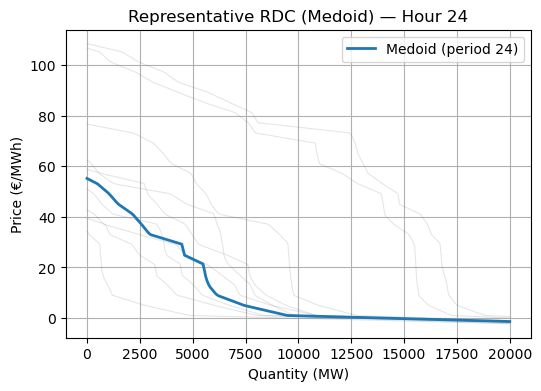

In [107]:
period_to_plot = 24
if period_to_plot in rep_curve_by_period:
    qg, prep = rep_curve_by_period[period_to_plot]
    raw_curves = raw_curves_by_period[period_to_plot]

    plt.figure(figsize=(6,4))
    for curve in raw_curves:
        plt.plot(curve['q'], curve['p'], alpha=0.2, lw=0.8, color='gray')
    plt.plot(qg, prep, lw=2.0, color='tab:blue',
             label=f"Medoid (period {period_to_plot:02d})")
    plt.xlabel("Quantity (MW)")
    plt.ylabel("Price (€/MWh)")
    plt.title(f"Representative RDC (Medoid) — Hour {period_to_plot:02d}")
    plt.legend()
    plt.grid(True)
    plt.show()

In [68]:
print(rep_curve_by_period.keys())          # 어떤 period가 저장됐는지


dict_keys([24])


modal curve

In [71]:
from sklearn.neighbors import KernelDensity

In [83]:

rep_curve_kde_by_period = {}

for period in range(1, 25):
    if period not in raw_curves_by_period:
        continue
    scenario_curves = raw_curves_by_period[period]
    if len(scenario_curves) < 2:
        continue

    # 공통 q-grid 정의 (합집합 범위 권장)
    q_min = min(curve['q'].min() for curve in scenario_curves)
    q_max = max(curve['q'].max() for curve in scenario_curves)
    q_grid = np.linspace(q_min, q_max, 300)

    # 각 시나리오를 q_grid 위에 보간
    P_rows = []
    for curve in scenario_curves:
        f_pq = interp1d(curve['q'], curve['p'], kind='linear',
                        bounds_error=False, fill_value="extrapolate")
        P_rows.append(f_pq(q_grid))
    P = np.vstack(P_rows)   # (S, m)

    # q_grid별로 KDE → 모드 추출
    p_kde = []
    for j in range(P.shape[1]):   # 각 q 지점
        samples = P[:, j].reshape(-1, 1)   # shape (S,1)
        kde = KernelDensity(kernel='gaussian', bandwidth=2.0).fit(samples)
        grid = np.linspace(samples.min()-5, samples.max()+5, 200).reshape(-1,1)
        log_dens = kde.score_samples(grid)
        p_mode = grid[np.argmax(log_dens)][0]
        p_kde.append(p_mode)

    rep_curve_kde_by_period[period] = (q_grid, np.array(p_kde))


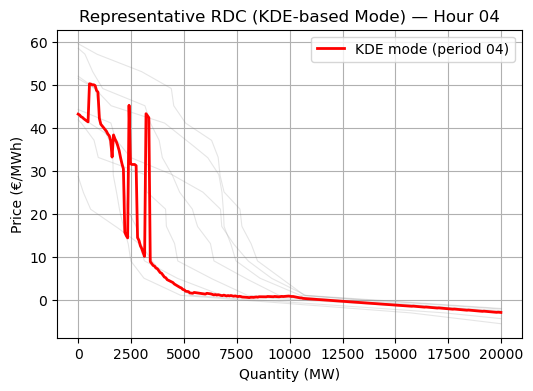

In [84]:
period_to_plot = 4

if period_to_plot in rep_curve_kde_by_period:
    qg, p_kde = rep_curve_kde_by_period[period_to_plot]
    raw_curves = raw_curves_by_period[period_to_plot]

    plt.figure(figsize=(6,4))
    for curve in raw_curves:
        plt.plot(curve['q'], curve['p'], alpha=0.2, lw=0.8, color='gray')
    plt.plot(qg, p_kde, lw=2.0, color='red',
             label=f"KDE mode (period {period_to_plot:02d})")
    plt.xlabel("Quantity (MW)")
    plt.ylabel("Price (€/MWh)")
    plt.title(f"Representative RDC (KDE-based Mode) — Hour {period_to_plot:02d}")
    plt.legend()
    plt.grid(True)
    plt.show()


In [117]:
from scipy.interpolate import interp1d
from sklearn.neighbors import KernelDensity
from sklearn.isotonic import IsotonicRegression
import numpy as np

# 1) 가격 격자 만들기 유틸
def make_price_grid(scenarios_S, scenarios_D, m=500):
    # 각 시나리오의 가격 범위 합집합 사용
    pmins = []; pmaxs = []
    for fS, fD in zip(scenarios_S, scenarios_D):
        # 함수 fS/fD 는 정의역 전체에서 동작하므로, 각자 내부에 저장한 원 범위를 돌려주게 만들거나
        # 바깥에서 min/max 가격을 함께 보관해 전달해도 됨.
        pass

# 2) KDE로 모달 곡선 추정 (가격별로 수량의 모드)
def modal_quantity_curve_by_kde(price_grid, q_matrix, bw=0.1, n_grid=200):
    """
    price_grid : shape (m,)
    q_matrix   : shape (S, m)  # 시나리오 S개 × 가격점 m개, 각 원소는 '수량'
    bw         : KDE bandwidth (수량축 스케일에 맞게 조절)
    반환       : q_mode (m,)
    """
    S, m = q_matrix.shape
    q_mode = np.zeros(m)
    for j in range(m):
        samples = q_matrix[:, j].reshape(-1, 1)
        # 샘플이 2개 이하이면 KDE가 불안정 → 중앙값 fallback
        if np.sum(np.isfinite(samples)) < 3:
            q_mode[j] = np.nanmedian(samples)
            continue
        kde = KernelDensity(kernel='gaussian', bandwidth=bw).fit(samples)
        lo, hi = np.nanmin(samples) - 0.05*(np.ptp(samples)+1e-9), np.nanmax(samples) + 0.05*(np.ptp(samples)+1e-9)
        grid = np.linspace(lo, hi, n_grid).reshape(-1,1)
        log_d = kde.score_samples(grid)
        q_mode[j] = grid[np.argmax(log_d)][0]
    return q_mode

# 3) 단조성 보정
def enforce_monotone(price_grid, q_vals, increasing=True):
    """ increasing=True → 비증가/비감소는 x,y 뒤집기 트릭으로 구현 """
    # IsotonicRegression은 x에 대해 y가 단조 '증가'로 맞추므로,
    # 수요(감소)를 맞추려면 y에 부호를 바꿔준다.
    ir = IsotonicRegression(increasing=True, out_of_bounds='clip')
    if increasing:  # 공급
        q_iso = ir.fit_transform(price_grid, q_vals)
    else:           # 수요(감소) → 부호 뒤집어 증가로 맞춘 뒤 다시 복구
        q_iso = -ir.fit_transform(price_grid, -q_vals)
    return q_iso

# 4) period 하나 처리: 모달 S/D → RDC
def build_modal_S_D_and_rdc_for_period(df_by_day_list, period, wf_offer_grid,
                                       m_price=500, bw_supply=200.0, bw_demand=200.0,
                                       enforce_iso=True):
    """
    df_by_day_list : [(date_str, df_day), ...]  # 각 day의 CSV를 읽어 필터링한 데이터프레임
    period         : 시간대(int)
    wf_offer_grid  : np.array([...])  # q 그리드 (MW)
    m_price        : 가격 격자 해상도
    bw_*           : KDE 대역폭(단위=MW; 수량 분포 폭에 맞게 조절)
    """
    scenarios = []
    for date_str, df in df_by_day_list:
        sub = df[df['Time Period'] == period]
        sup = sub[sub['GC'] == 'V']
        dem = sub[sub['GC'] == 'C']
        if sup.empty or dem.empty:
            continue

        s_agg = sup.groupby('Price')['Amount'].sum().reset_index().sort_values('Price')
        s_agg['Cumul'] = s_agg['Amount'].cumsum()
        d_agg = dem.groupby('Price')['Amount'].sum().reset_index().sort_values('Price')
        d_agg['Cumul'] = d_agg['Amount'][::-1].cumsum()[::-1]

        # 계단 보간: 공급 증가, 수요 감소
        fS = interp1d(s_agg['Price'], s_agg['Cumul'], kind='previous',
                      bounds_error=False, fill_value=(0, s_agg['Cumul'].iat[-1]))
        fD = interp1d(d_agg['Price'], d_agg['Cumul'], kind='previous',
                      bounds_error=False, fill_value=(d_agg['Cumul'].iat[0], 0))
        pmin = float(min(s_agg['Price'].min(), d_agg['Price'].min()))
        pmax = float(max(s_agg['Price'].max(), d_agg['Price'].max()))
        scenarios.append((fS, fD, pmin, pmax))

    if len(scenarios) < 2:
        return None  # 모달 추정 의미 없음

    p_min = min(pmin for _,_,pmin,_ in scenarios)
    p_max = max(pmax for _,_,_,pmax in scenarios)
    P = np.linspace(p_min, p_max, m_price)

    # 시나리오별 S/D를 같은 가격격자에 평가 → (S, m)
    S_rows = []
    D_rows = []
    for fS, fD, _, _ in scenarios:
        S_rows.append(fS(P))
        D_rows.append(fD(P))
    S_mat = np.vstack(S_rows)   # 공급
    D_mat = np.vstack(D_rows)   # 수요

    # 가격별 KDE로 '수량의 모드' 추정
    S_mode = modal_quantity_curve_by_kde(P, S_mat, bw=bw_supply)
    D_mode = modal_quantity_curve_by_kde(P, D_mat, bw=bw_demand)

    # (선택) 단조성 보정
    if enforce_iso:
        S_mode = enforce_monotone(P, S_mode, increasing=True)   # 공급 비감소
        D_mode = enforce_monotone(P, D_mode, increasing=False)  # 수요 비증가

    # 모달 공급/수요로 RDC 재계산
    rdc_pts = compute_rdc_by_sign_change(P, demand_vals=D_mode, supply_vals=S_mode,
                                         wf_offers=wf_offer_grid)
    return P, S_mode, D_mode, rdc_pts


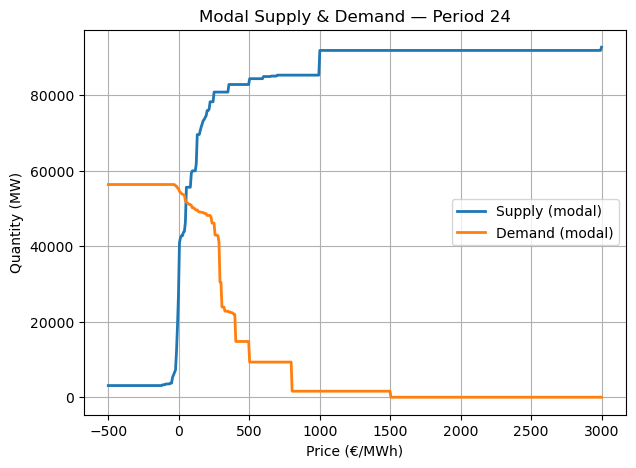

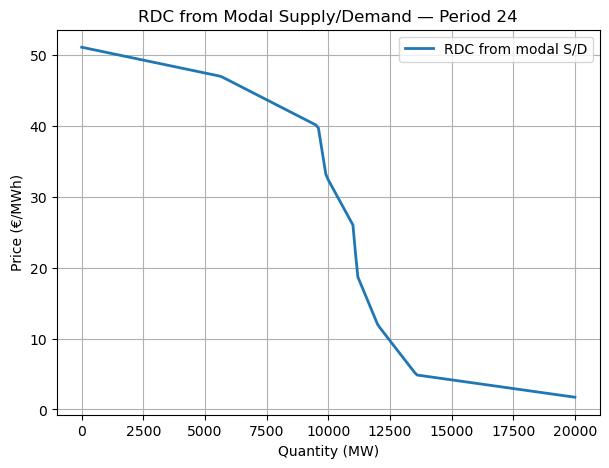

In [ ]:
# 데이터 읽기(예: 10일치)
days = set(range(20, 30))-  # 7/20~7/29
df_by_day_list = []
for d in days:
    date_str = f"202507{d:02d}"
    try:
        df = pd.read_csv(f"filteredcurve_{date_str}.csv", encoding="utf-8-sig")
        df_by_day_list.append((date_str, df))
    except FileNotFoundError:
        pass

wf_offer_grid = np.arange(0, 20001, 100)  # MW

period = 24
res = build_modal_S_D_and_rdc_for_period(df_by_day_list, period, wf_offer_grid,
                                         m_price=500, bw_supply=300.0, bw_demand=300.0,
                                         enforce_iso=True)
if res is not None:
    P, S_mode, D_mode, rdc_pts = res
    # 플롯
    plt.figure(figsize=(7,5))
    plt.plot(P, S_mode, label="Supply (modal)", lw=2)
    plt.plot(P, D_mode, label="Demand (modal)", lw=2)
    plt.xlabel("Price (€/MWh)")
    plt.ylabel("Quantity (MW)")
    plt.title(f"Modal Supply & Demand — Period {period:02d}")
    plt.legend(); plt.grid(True); plt.show()

    if rdc_pts:
        qv, pv = zip(*rdc_pts); qv = np.array(qv); pv = np.array(pv)
        plt.figure(figsize=(7,5))
        plt.plot(qv, pv, lw=2, label="RDC from modal S/D")
        plt.xlabel("Quantity (MW)"); plt.ylabel("Price (€/MWh)")
        plt.title(f"RDC from Modal Supply/Demand — Period {period:02d}")
        plt.grid(True); plt.legend(); plt.show()


In [124]:
# 데이터 읽기(예: 10일치)
days = set(range(20, 30)) - {21,22}
# days = range(20, 30)

df_by_day_list = []
for d in days:
    date_str = f"202507{d:02d}"
    try:
        df = pd.read_csv(f"filteredcurve_{date_str}.csv", encoding="utf-8-sig")
        df_by_day_list.append((date_str, df))
    except FileNotFoundError:
        pass

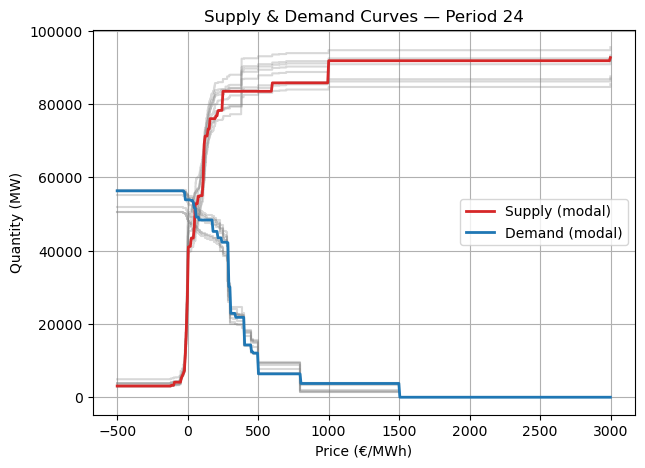

In [126]:
period = 24
res = build_modal_S_D_and_rdc_for_period(df_by_day_list, period, wf_offer_grid,
                                         m_price=500, bw_supply=120.0, bw_demand=120.0,
                                         enforce_iso=True)
if res is not None:
    P, S_mode, D_mode, rdc_pts = res

    plt.figure(figsize=(7,5))
    # 1) 원시 시나리오별 S/D 곡선
    for date_str, df in df_by_day_list:
        sub = df[df['Time Period'] == period]
        sup = sub[sub['GC']=='V']
        dem = sub[sub['GC']=='C']
        if sup.empty or dem.empty:
            continue

        s_agg = sup.groupby('Price')['Amount'].sum().reset_index().sort_values('Price')
        s_agg['Cumul'] = s_agg['Amount'].cumsum()

        d_agg = dem.groupby('Price')['Amount'].sum().reset_index().sort_values('Price')
        d_agg['Cumul'] = d_agg['Amount'][::-1].cumsum()[::-1]

        plt.step(s_agg['Price'], s_agg['Cumul'], where='post', color='gray', alpha=0.3)
        plt.step(d_agg['Price'], d_agg['Cumul'], where='post', color='gray', alpha=0.3)

    # 2) Modal KDE 기반 곡선
    plt.plot(P, S_mode, label="Supply (modal)", lw=2, color='tab:red')
    plt.plot(P, D_mode, label="Demand (modal)", lw=2, color='tab:blue')

    plt.xlabel("Price (€/MWh)")
    plt.ylabel("Quantity (MW)")
    plt.title(f"Supply & Demand Curves — Period {period:02d}")
    plt.legend(); plt.grid(True); plt.show()


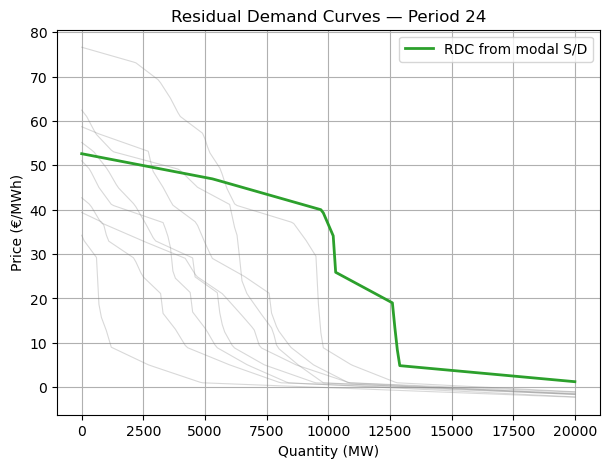

In [127]:
if rdc_pts:
    qv, pv = zip(*rdc_pts)
    qv, pv = np.array(qv), np.array(pv)

    plt.figure(figsize=(7,5))
    # 1) 원시 시나리오별 RDC
    for date_str, df in df_by_day_list:
        sub = df[df['Time Period'] == period]
        sup = sub[sub['GC']=='V']
        dem = sub[sub['GC']=='C']
        if sup.empty or dem.empty:
            continue

        # 보간 후 RDC 생성
        s_agg = sup.groupby('Price')['Amount'].sum().reset_index().sort_values('Price')
        s_agg['Cumul'] = s_agg['Amount'].cumsum()
        d_agg = dem.groupby('Price')['Amount'].sum().reset_index().sort_values('Price')
        d_agg['Cumul'] = d_agg['Amount'][::-1].cumsum()[::-1]

        s_f = interp1d(s_agg['Price'], s_agg['Cumul'], kind='previous',
                       bounds_error=False, fill_value=(0, s_agg['Cumul'].iat[-1]))
        d_f = interp1d(d_agg['Price'], d_agg['Cumul'], kind='previous',
                       bounds_error=False, fill_value=(d_agg['Cumul'].iat[0], 0))
        pg = np.linspace(s_agg['Price'].min(), d_agg['Price'].max(), 500)
        sv, dv = s_f(pg), d_f(pg)

        rdc_pts_scn = compute_rdc_by_sign_change(pg, dv, sv, wf_offer_grid)
        if rdc_pts_scn:
            q_scn, p_scn = zip(*rdc_pts_scn)
            plt.plot(q_scn, p_scn, color='gray', alpha=0.3, lw=0.8)

    # 2) Modal 기반 RDC
    plt.plot(qv, pv, lw=2, color='tab:green', label="RDC from modal S/D")

    plt.xlabel("Quantity (MW)")
    plt.ylabel("Price (€/MWh)")
    plt.title(f"Residual Demand Curves — Period {period:02d}")
    plt.legend(); plt.grid(True); plt.show()


Clustering

In [129]:
period = 24
P_grid = np.linspace(0, 200, 500)  # 가격 그리드 (€/MWh), 원하는 해상도로

S_rows, D_rows, meta = [], [], []

for date_str, df in df_by_day_list:
    sub = df[df['Time Period'] == period]
    sup = sub[sub['GC']=='V']
    dem = sub[sub['GC']=='C']
    if sup.empty or dem.empty:
        continue

    # --- Supply curve ---
    s_agg = sup.groupby('Price')['Amount'].sum().reset_index().sort_values('Price')
    s_agg['Cumul'] = s_agg['Amount'].cumsum()
    f_s = interp1d(s_agg['Price'], s_agg['Cumul'],
                   kind='previous', bounds_error=False,
                   fill_value=(0, s_agg['Cumul'].iat[-1]))

    # --- Demand curve ---
    d_agg = dem.groupby('Price')['Amount'].sum().reset_index().sort_values('Price')
    d_agg['Cumul'] = d_agg['Amount'][::-1].cumsum()[::-1]
    f_d = interp1d(d_agg['Price'], d_agg['Cumul'],
                   kind='previous', bounds_error=False,
                   fill_value=(d_agg['Cumul'].iat[0], 0))

    # --- 공통 grid에 보간 ---
    S_rows.append(f_s(P_grid))
    D_rows.append(f_d(P_grid))
    meta.append(date_str)

# numpy 행렬화
S_mat = np.vstack(S_rows)   # shape = (n_days, len(P_grid))
D_mat = np.vstack(D_rows)   # shape = (n_days, len(P_grid))


In [130]:
from sklearn.cluster import KMeans

k = 2  # 클러스터 개수
kmeans_s = KMeans(n_clusters=k, random_state=0).fit(S_mat)
labels_s = kmeans_s.labels_
centers_s = kmeans_s.cluster_centers_

kmeans_d = KMeans(n_clusters=k, random_state=0).fit(D_mat)
labels_d = kmeans_d.labels_
centers_d = kmeans_d.cluster_centers_

In [131]:
import numpy as np

def get_medoid(mat, labels, cluster_id):
    idx = np.where(labels == cluster_id)[0]
    cluster_points = mat[idx]
    dists = np.linalg.norm(cluster_points[:, None, :] - cluster_points[None, :, :], axis=2).sum(axis=1)
    medoid_idx = idx[np.argmin(dists)]
    return medoid_idx


IndexError: index 8 is out of bounds for axis 0 with size 8

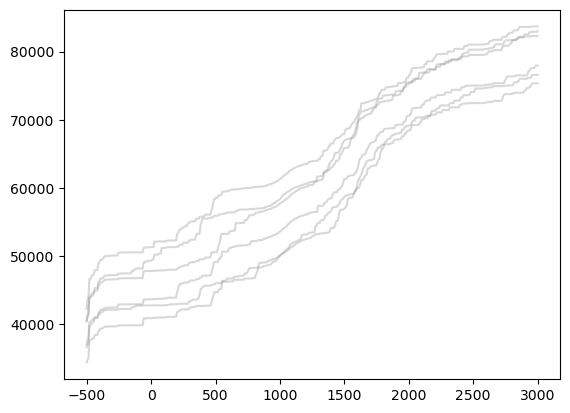

In [132]:
cluster_id = 0
plt.figure()
for i in np.where(labels==cluster_id)[0]:
    plt.plot(P, S_mat[i], color='gray', alpha=0.3)
plt.plot(P, centers[cluster_id, :m], color='red', lw=2, label="Cluster 0 mean supply")
plt.legend(); plt.grid(True)


In [133]:
from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# 1) period의 공급곡선을 공통 price grid에 보간 → S_mat, meta
def build_S_matrix(df_by_day_list, period, p_min=None, p_max=None, m=500):
    S_rows, meta = [], []

    # 먼저 각 day의 price 범위 확인
    pmins, pmaxs = [], []
    tmp_funcs = []
    for date_str, df in df_by_day_list:
        sub = df[df['Time Period'] == period]
        sup = sub[sub['GC']=='V']
        if sup.empty:
            continue
        s_agg = (sup.groupby('Price')['Amount']
                    .sum().reset_index()
                    .sort_values('Price'))
        s_agg['Cumul'] = s_agg['Amount'].cumsum()
        f_s  = interp1d(s_agg['Price'], s_agg['Cumul'], kind='previous',
                        bounds_error=False, fill_value=(0, s_agg['Cumul'].iat[-1]))
        pmins.append(s_agg['Price'].min())
        pmaxs.append(s_agg['Price'].max())
        tmp_funcs.append((date_str, f_s))

    if not tmp_funcs:
        raise ValueError("No supply curves for this period.")

    # 공통 price grid
    if p_min is None: p_min = float(min(pmins))
    if p_max is None: p_max = float(max(pmaxs))
    P_grid = np.linspace(p_min, p_max, m)

    # 실제 행렬 만들기
    for date_str, f_s in tmp_funcs:
        S_rows.append(f_s(P_grid))
        meta.append(date_str)

    S_mat = np.vstack(S_rows)  # shape = (n, m)
    return P_grid, S_mat, meta

# 2) KMeans로 S_mat 클러스터링 (k=2)
def cluster_supply_curves(S_mat, k=2, random_state=0):
    km = KMeans(n_clusters=k, random_state=random_state)
    km.fit(S_mat)
    labels = km.labels_                 # 길이 = S_mat.shape[0]
    centers = km.cluster_centers_       # shape = (k, m)
    return labels, centers

# 3) 시각화 (라벨과 행렬을 반드시 같은 것 사용!)
def plot_supply_cluster(P_grid, S_mat, labels, centers, cluster_id):
    # 방어: 길이 일치 확인
    assert S_mat.shape[0] == len(labels), f"rows={S_mat.shape[0]}, labels={len(labels)}"

    idxs = np.where(labels == cluster_id)[0]
    if len(idxs) == 0:
        print(f"No members in cluster {cluster_id}")
        return

    plt.figure(figsize=(6,4))
    for i in idxs:
        plt.plot(P_grid, S_mat[i], color='gray', alpha=0.3, lw=0.9)

    plt.plot(P_grid, centers[cluster_id], color='red', lw=2,
             label=f"Cluster {cluster_id} mean supply")
    plt.xlabel("Price (€/MWh)")
    plt.ylabel("Quantity (MW)")
    plt.title(f"Supply Curves — Cluster {cluster_id}")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


S_mat rows: 8 labels: 8


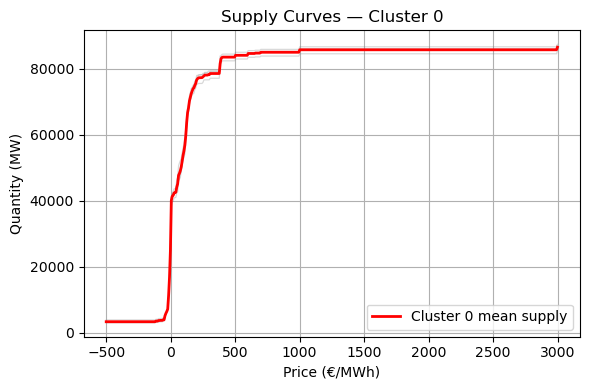

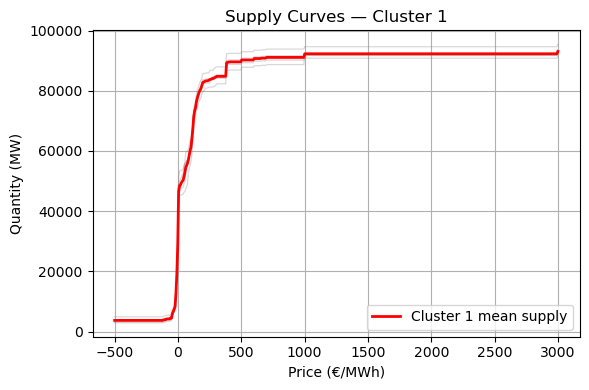

In [135]:
period = 24
P_grid, S_mat, meta = build_S_matrix(df_by_day_list, period, m=500)

labels_s, centers_s = cluster_supply_curves(S_mat, k=2, random_state=0)

# 디버깅: 반드시 길이 체크
print("S_mat rows:", S_mat.shape[0], "labels:", len(labels_s))

# 클러스터 0, 1 모두 그려보기
plot_supply_cluster(P_grid, S_mat, labels_s, centers_s, cluster_id=0)
plot_supply_cluster(P_grid, S_mat, labels_s, centers_s, cluster_id=1)


In [136]:
from scipy.interpolate import interp1d
labels_s, centers_s = cluster_supply_curves(S_mat, k=2)
labels_d, centers_d = cluster_supply_curves(D_mat, k=2)
def rdc_from_curves(P_grid, S_curve, D_curve, wf_offer_grid):
    # 보간 함수
    f_s = interp1d(P_grid, S_curve, kind='linear', bounds_error=False,
                   fill_value=(0, S_curve[-1]))
    f_d = interp1d(P_grid, D_curve, kind='linear', bounds_error=False,
                   fill_value=(D_curve[0], 0))

    sv, dv = f_s(P_grid), f_d(P_grid)
    rdc_pts = compute_rdc_by_sign_change(P_grid, dv, sv, wf_offer_grid)
    return rdc_pts


In [137]:
wf_offer_grid = np.arange(0, 20001, 100)
rdc_clusters = []

for i, S_curve in enumerate(centers_s):
    for j, D_curve in enumerate(centers_d):
        rdc_pts = rdc_from_curves(P_grid, S_curve, D_curve, wf_offer_grid)
        if rdc_pts:
            qv, pv = zip(*rdc_pts)
            rdc_clusters.append({
                's_cluster': i,
                'd_cluster': j,
                'q': np.array(qv),
                'p': np.array(pv)
            })


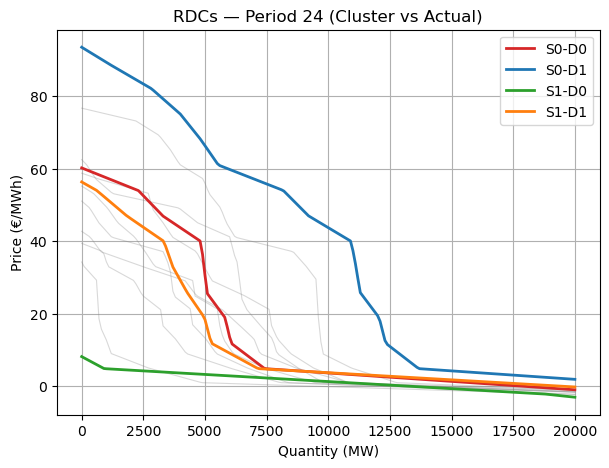

In [138]:
plt.figure(figsize=(7,5))

# 원래 시나리오별 RDC (회색)
for date_str, df in df_by_day_list:
    sub = df[df['Time Period'] == period]
    sup, dem = sub[sub['GC']=='V'], sub[sub['GC']=='C']
    if sup.empty or dem.empty:
        continue

    s_agg = sup.groupby('Price')['Amount'].sum().reset_index().sort_values('Price')
    s_agg['Cumul'] = s_agg['Amount'].cumsum()
    d_agg = dem.groupby('Price')['Amount'].sum().reset_index().sort_values('Price')
    d_agg['Cumul'] = d_agg['Amount'][::-1].cumsum()[::-1]

    s_f = interp1d(s_agg['Price'], s_agg['Cumul'], kind='previous',
                   bounds_error=False, fill_value=(0, s_agg['Cumul'].iat[-1]))
    d_f = interp1d(d_agg['Price'], d_agg['Cumul'], kind='previous',
                   bounds_error=False, fill_value=(d_agg['Cumul'].iat[0], 0))
    pg = np.linspace(s_agg['Price'].min(), d_agg['Price'].max(), 500)
    sv, dv = s_f(pg), d_f(pg)

    rdc_pts_scn = compute_rdc_by_sign_change(pg, dv, sv, wf_offer_grid)
    if rdc_pts_scn:
        q_scn, p_scn = zip(*rdc_pts_scn)
        plt.plot(q_scn, p_scn, color='gray', alpha=0.3, lw=0.8)

# 클러스터 조합 RDC (컬러)
colors = ['tab:red', 'tab:blue', 'tab:green', 'tab:orange']
for k, r in enumerate(rdc_clusters):
    plt.plot(r['q'], r['p'], lw=2, color=colors[k % len(colors)],
             label=f"S{r['s_cluster']}-D{r['d_cluster']}")

plt.xlabel("Quantity (MW)")
plt.ylabel("Price (€/MWh)")
plt.title(f"RDCs — Period {period:02d} (Cluster vs Actual)")
plt.legend()
plt.grid(True)
plt.show()


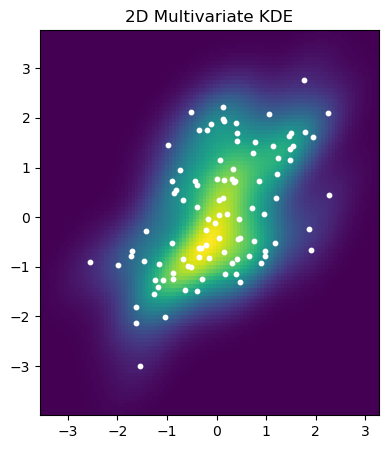

In [85]:
import numpy as np
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt

# 샘플 데이터 (2차원)
np.random.seed(0)
x = np.random.normal(size=100)
y = x*0.5 + np.random.normal(size=100)

data = np.vstack([x, y])  # shape (2, n)

# KDE 적합
kde = gaussian_kde(data)

# 격자 만들기
xmin, xmax = x.min()-1, x.max()+1
ymin, ymax = y.min()-1, y.max()+1
X, Y = np.mgrid[xmin:xmax:100j, ymin:ymax:100j]
positions = np.vstack([X.ravel(), Y.ravel()])

# KDE 밀도 계산
Z = np.reshape(kde(positions).T, X.shape)

# 시각화
plt.figure(figsize=(6,5))
plt.imshow(np.rot90(Z), cmap=plt.cm.viridis,
           extent=[xmin, xmax, ymin, ymax])
plt.scatter(x, y, s=10, color='white')
plt.title("2D Multivariate KDE")
plt.show()


In [86]:
all_points = []  # (q,p) 전체 시나리오 점 모음

for period in range(1, 25):
    scenario_curves = raw_curves_by_period.get(period, [])
    for curve in scenario_curves:
        qv, pv = curve['q'], curve['p']
        pts = np.vstack([qv, pv]).T
        all_points.append(pts)

all_points = np.vstack(all_points)  # shape (N, 2)
print("총 샘플 개수:", all_points.shape)


총 샘플 개수: (384002, 2)


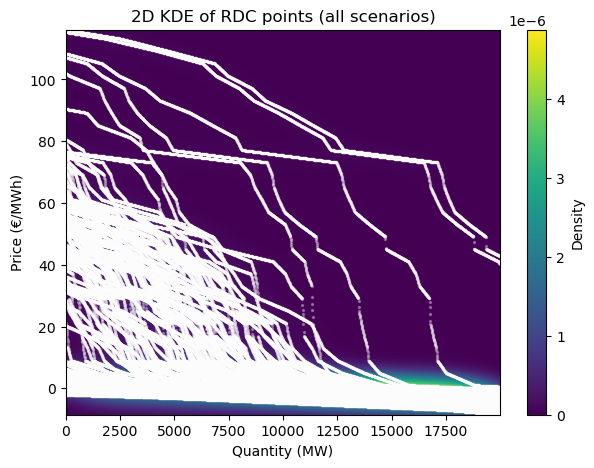

In [87]:
from scipy.stats import gaussian_kde

# KDE 적합
kde = gaussian_kde(all_points.T, bw_method=0.2)  # bw_method는 bandwidth

# 격자 정의
qmin, qmax = all_points[:,0].min(), all_points[:,0].max()
pmin, pmax = all_points[:,1].min(), all_points[:,1].max()

Q, P = np.mgrid[qmin:qmax:200j, pmin:pmax:200j]   # 200x200 grid
positions = np.vstack([Q.ravel(), P.ravel()])

# 밀도 추정
Z = np.reshape(kde(positions).T, Q.shape)

# 시각화
plt.figure(figsize=(7,5))
plt.imshow(np.rot90(Z), cmap='viridis',
           extent=[qmin, qmax, pmin, pmax],
           aspect='auto')
plt.colorbar(label="Density")
plt.scatter(all_points[:,0], all_points[:,1], s=2, color='white', alpha=0.3)
plt.xlabel("Quantity (MW)")
plt.ylabel("Price (€/MWh)")
plt.title("2D KDE of RDC points (all scenarios)")
plt.show()


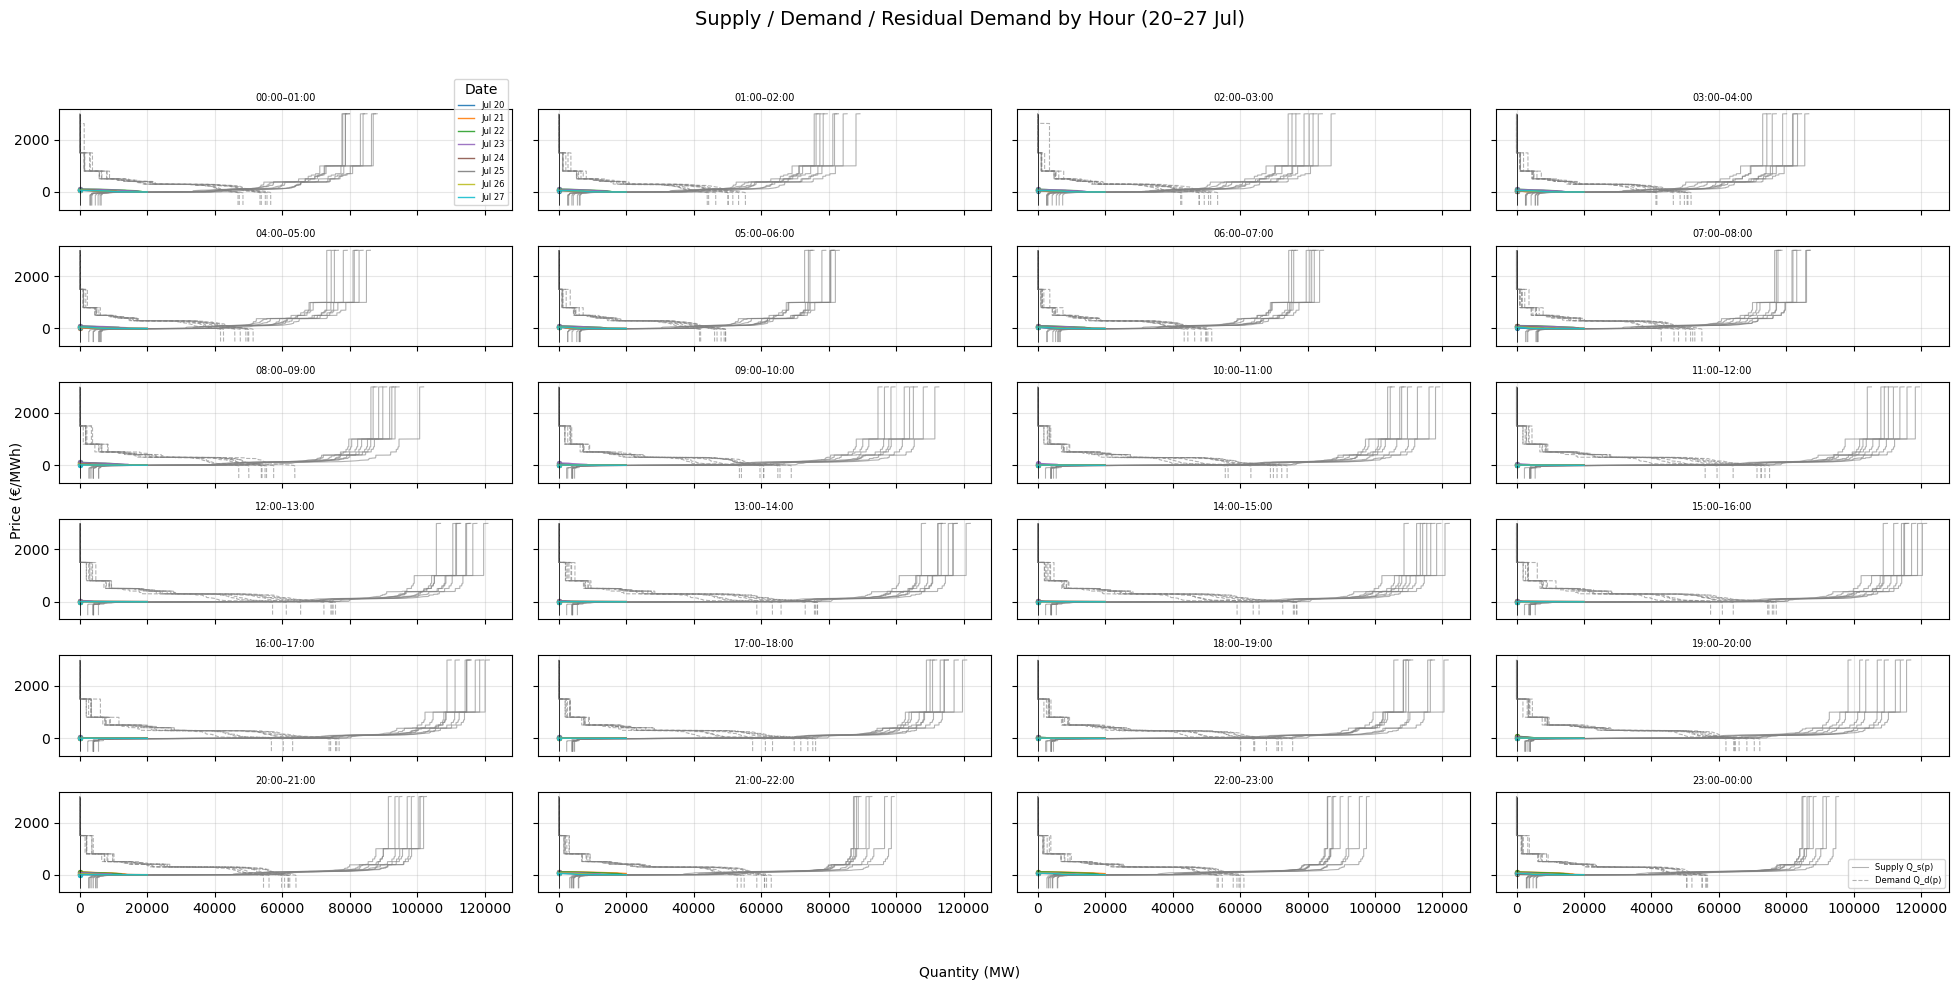

In [93]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.optimize import root_scalar

plt.close('all')  # 이전 그림 정리

# ── A) 보조함수
def compute_rdc_by_sign_change(price_grid, demand_vals, supply_vals, wf_offers):
    rdc = []
    for q in wf_offers:
        resid = demand_vals - supply_vals - q
        idx   = np.where(np.diff(np.sign(resid)) != 0)[0]
        for i in idx:
            p0,p1 = price_grid[i], price_grid[i+1]
            r0,r1 = resid[i],       resid[i+1]
            if r1 != r0:
                p_star = p0 - r0*(p1-p0)/(r1-r0)
                rdc.append((q, p_star))
    return rdc

# ── B) 공통 설정
days   = range(20,28)  # 7/20~7/27
colors = plt.cm.tab10(np.linspace(0,1,len(days)))

qini, qmax, lambda_da_block, orig_cp = {}, {}, {}, {}
date_labels_added = False

# ── C) Figure 생성 (6x4 = 24개 축)
fig, axes = plt.subplots(nrows=6, ncols=4, figsize=(20,10), sharex=True, sharey=True)
axes = axes.flatten()

for period in range(1,25):
    ax = axes[period-1]
    handles_for_dates = []
    plotted_any = False  # 이 period에서 뭔가라도 그렸는지 체크

    for day, color in zip(days, colors):
        date_str = f"202507{day:02d}"
        fn       = f"filteredcurve_{date_str}.csv"
        try:
            df = pd.read_csv(fn, encoding='utf-8-sig')
        except FileNotFoundError:
            continue

        sub = df[df['Time Period']==period]
        sup = sub[sub['GC']=='V']
        dem = sub[sub['GC']=='C']
        if sup.empty or dem.empty:
            continue

        s_agg = (sup.groupby('Price')['Amount'].sum().reset_index().sort_values('Price'))
        s_agg['Cumul'] = s_agg['Amount'].cumsum()

        d_agg = (dem.groupby('Price')['Amount'].sum().reset_index().sort_values('Price'))
        d_agg['Cumul'] = d_agg['Amount'][::-1].cumsum()[::-1]

        # 가격 그리드 만들 때 min==max 예외 처리
        pmin = min(s_agg['Price'].min(), d_agg['Price'].min())
        pmax = max(s_agg['Price'].max(), d_agg['Price'].max())
        if not np.isfinite(pmin) or not np.isfinite(pmax) or pmin >= pmax:
            continue

        # 계단형 보간 (P->Q)
        s_f = interp1d(s_agg['Price'], s_agg['Cumul'], kind='previous',
                       bounds_error=False, fill_value=(0, s_agg['Cumul'].iat[-1]))
        d_f = interp1d(d_agg['Price'], d_agg['Cumul'], kind='previous',
                       bounds_error=False, fill_value=(d_agg['Cumul'].iat[0], 0))

        pg = np.linspace(pmin, pmax, 600)
        sv = s_f(pg)  # Q_s(p)
        dv = d_f(pg)  # Q_d(p)

        # 원래 균형가격
        def resid0(p): return d_f(p) - s_f(p)
        try:
            sol0 = root_scalar(resid0, bracket=[pg[0], pg[-1]], method='bisect')
            cp0 = sol0.root if sol0.converged else np.nan
        except ValueError:
            cp0 = np.nan
        orig_cp[(date_str,period)] = cp0

        # RDC
        wf_offer_grid = np.arange(0, 20000, 10)
        rdc_pts = compute_rdc_by_sign_change(pg, dv, sv, wf_offer_grid)
        if not rdc_pts:
            continue
        qv, pv = map(np.array, zip(*rdc_pts))

        # 공급/수요 (Q,P)
        ax.plot(sv, pg, color='0.5', linewidth=0.8, alpha=0.6)
        ax.plot(dv, pg, color='0.5', linewidth=0.8, alpha=0.6, linestyle='--')

        # RDC
        lbl = f"Jul {day}" if not date_labels_added else None
        line_rdc, = ax.plot(qv, pv, '-', color=color, linewidth=1.0, alpha=0.9, label=lbl)
        if not date_labels_added and lbl is not None:
            handles_for_dates.append(line_rdc)

        # 균형가격 표시
        if np.isfinite(cp0):
            ax.scatter([0], [cp0], s=8, color=color, alpha=0.9)
            ax.vlines(0, ymin=pg.min(), ymax=pg.max(), color='k', linewidth=0.4, alpha=0.3)

        # 블록 저장
        delta_qs = np.diff(wf_offer_grid)
        for b, (q0, dq) in enumerate(zip(wf_offer_grid[:-1], delta_qs)):
            mid = q0 + dq/2
            qini[(date_str,period,b)] = float(q0)
            qmax[(date_str,period,b)] = float(dq)
            lambda_da_block[(date_str,period,b)] = float(np.interp(mid, qv, pv))

        plotted_any = True  # 이 period에서 뭔가 그림

    # 제목/그리드/범례
    hh1 = f"{period-1:02d}:00"; hh2 = f"{period%24:02d}:00"
    ax.set_title(f"{hh1}–{hh2}", fontsize=7)
    ax.grid(True, alpha=0.3)

    # 첫 서브플롯에만 날짜 범례
    if (period == 1) and (not date_labels_added) and handles_for_dates:
        ax.legend(handles=handles_for_dates, title='Date', fontsize=6, loc='lower right', frameon=True)
        date_labels_added = True

    # 데이터가 하나도 없었으면 안내문 남기기
    if not plotted_any:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes, fontsize=8, color='0.4')

# 공통 레이아웃
fig.supxlabel('Quantity (MW)', fontsize=10)
fig.supylabel('Price (€/MWh)', fontsize=10)
fig.suptitle('Supply / Demand / Residual Demand by Hour (20–27 Jul)', fontsize=14)

# Supply/Demand 표식 설명(마지막 축)
last_ax = axes[-1]
s1 = last_ax.plot([], [], color='0.5', lw=0.8, alpha=0.6)[0]
s2 = last_ax.plot([], [], color='0.5', lw=0.8, alpha=0.6, ls='--')[0]
last_ax.legend([s1, s2], ['Supply Q_s(p)', 'Demand Q_d(p)'], fontsize=6, loc='lower right', frameon=True)

plt.tight_layout(rect=[0,0.03,1,0.95])
plt.show()
